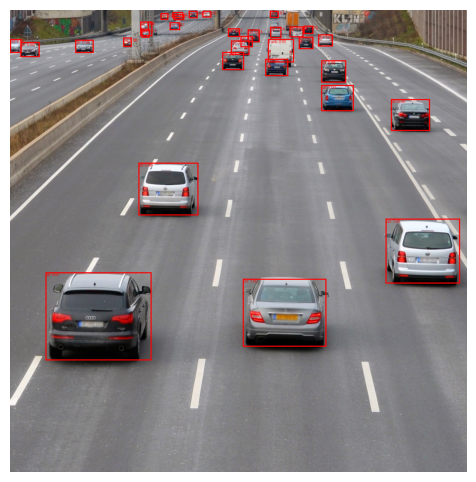

In [ ]:
import torch
import torchvision.transforms as T
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from torchvision.models.detection import fasterrcnn_resnet50_fpn

# Load COCO class labels
COCO_CLASSES = [
    "__background__", "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse",
    "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie",
    "suitcase", "frisbee", "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon",
    "bowl", "banana", "apple", "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut",
    "cake", "chair", "couch", "potted plant", "bed", "dining table", "toilet", "TV", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush"
]

# Load a pre-trained Faster R-CNN model
model = fasterrcnn_resnet50_fpn(pretrained=True)
model.eval()  # Set to evaluation mode

# Load and preprocess the image
image_path = "/content/ev.jpg!d"  # Change this to your image path
image = Image.open(image_path).convert("RGB")

# Transform image to tensor
transform = T.Compose([T.ToTensor()])
image_tensor = transform(image).unsqueeze(0)  # Add batch dimension

# Run inference
with torch.no_grad():
    predictions = model(image_tensor)

# Extract predictions
boxes = predictions[0]['boxes']
labels = predictions[0]['labels']
scores = predictions[0]['scores']

# Define a threshold to filter weak detections
threshold = 0.5
filtered_boxes = [(box, label, score) for box, label, score in zip(boxes, labels, scores) if score > threshold]

# Draw bounding boxes
draw = ImageDraw.Draw(image)

for box, label, score in filtered_boxes:
    box = box.tolist()
    label_name = COCO_CLASSES[label]  # Convert label index to class name
    draw.rectangle(box, outline="red", width=3)
    draw.text((box[0], box[1]), f"{label_name}: {score:.2f}", fill="red")

# Display the image with detections
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.show()
